# Linear

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs, make_moons, make_circles

# Data: Linearly Separable (Blobs)
X, y = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=0.8)

# Train Linear SVM
clf = SVC(kernel='linear')
clf.fit(X, y)

# Parameters
w = clf.coef_[0]
b = clf.intercept_[0]

# Decision boundary
x = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
# To avoid division by zero if w[1] is 0, add a small epsilon
epsilon = 1e-10
y_line = -(w[0]*x + b) / (w[1] + epsilon)

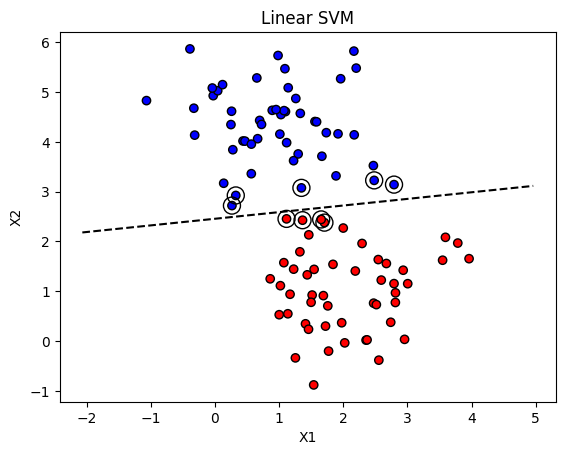

In [ ]:
# Plot
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k')
plt.plot(x, y_line, 'k--')
plt.scatter(clf.support_vectors_[:,0],
            clf.support_vectors_[:,1],
            s=150, facecolors='none', edgecolors='k')
plt.xlabel("X1"); plt.ylabel("X2")
plt.title("Linear SVM")
plt.show()


# Polynomial

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Train Polynomial SVM
clf_poly = SVC(kernel='poly', degree=3)
clf_poly.fit(X, y)

# Create a meshgrid to plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Predict the class for each point in the meshgrid
Z_poly = clf_poly.predict(np.c_[xx.ravel(), yy.ravel()])
Z_poly = Z_poly.reshape(xx.shape)

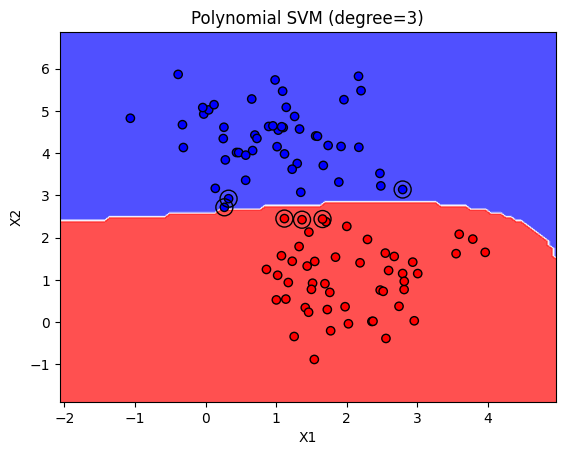

In [ ]:
# Plot Polynomial SVM
plt.contourf(xx, yy, Z_poly, alpha=0.8, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.scatter(clf_poly.support_vectors_[:, 0],
            clf_poly.support_vectors_[:, 1],
            s=150, facecolors='none', edgecolors='k', label='Support Vectors')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Polynomial SVM (degree=3)")
plt.show()

# RBF

# Moons Dataset

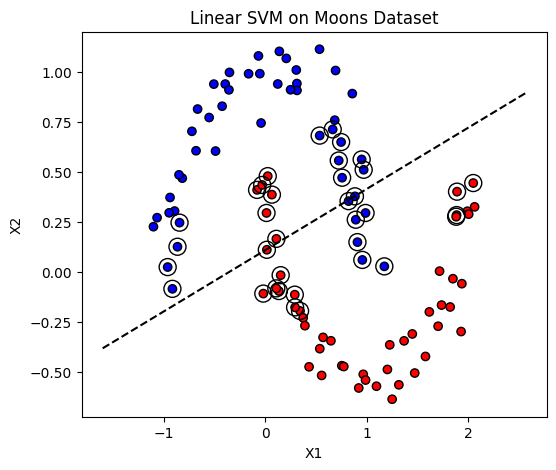

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_moons

# Data: Moons Dataset
X_moons, y_moons = make_moons(n_samples=100, noise=0.1, random_state=0)

# Train Linear SVM on Moons
clf_linear_moons = SVC(kernel='linear')
clf_linear_moons.fit(X_moons, y_moons)

# Parameters
w_moons = clf_linear_moons.coef_[0]
b_moons = clf_linear_moons.intercept_[0]

# Decision boundary for Linear Moons
x_moons_line = np.linspace(X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5, 100)
epsilon = 1e-10 # To avoid division by zero
y_moons_line = -(w_moons[0]*x_moons_line + b_moons) / (w_moons[1] + epsilon)

# Plot Linear Moons SVM
plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='bwr', edgecolors='k')
plt.plot(x_moons_line, y_moons_line, 'k--')
plt.scatter(clf_linear_moons.support_vectors_[:, 0],
            clf_linear_moons.support_vectors_[:, 1],
            s=150, facecolors='none', edgecolors='k')
plt.xlabel("X1"); plt.ylabel("X2")
plt.title("Linear SVM on Moons Dataset")
plt.show()

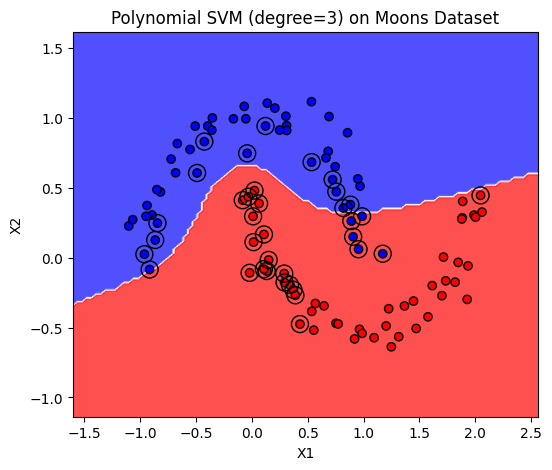

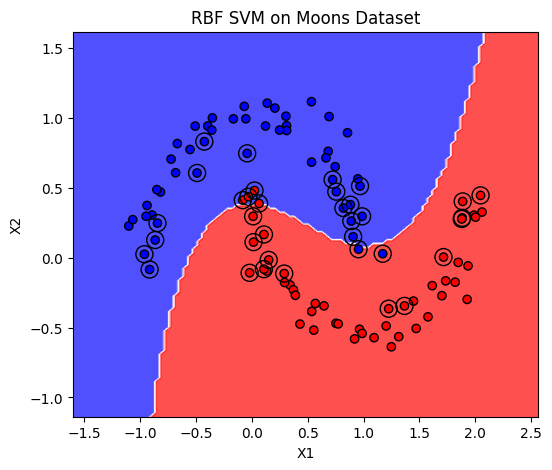

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_moons

# Reuse Moons Data (X_moons, y_moons) from previous cell, or redefine if running standalone
if 'X_moons' not in locals():
    X_moons, y_moons = make_moons(n_samples=100, noise=0.1, random_state=0)

# Create meshgrid for decision boundaries
x_min_m, x_max_m = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min_m, y_max_m = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
xx_m, yy_m = np.meshgrid(np.linspace(x_min_m, x_max_m, 100),
                         np.linspace(y_min_m, y_max_m, 100))

# Train Polynomial SVM on Moons
clf_poly_moons = SVC(kernel='poly', degree=3)
clf_poly_moons.fit(X_moons, y_moons)
Z_poly_moons = clf_poly_moons.predict(np.c_[xx_m.ravel(), yy_m.ravel()])
Z_poly_moons = Z_poly_moons.reshape(xx_m.shape)

# Plot Polynomial Moons SVM
plt.figure(figsize=(6, 5))
plt.contourf(xx_m, yy_m, Z_poly_moons, alpha=0.8, cmap='bwr')
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='bwr', edgecolors='k')
plt.scatter(clf_poly_moons.support_vectors_[:, 0],
            clf_poly_moons.support_vectors_[:, 1],
            s=150, facecolors='none', edgecolors='k', label='Support Vectors')
plt.xlabel("X1"); plt.ylabel("X2")
plt.title("Polynomial SVM (degree=3) on Moons Dataset")
plt.show()

# Train RBF SVM on Moons
clf_rbf_moons = SVC(kernel='rbf', gamma='auto') # Using 'auto' gamma for simplicity
clf_rbf_moons.fit(X_moons, y_moons)
Z_rbf_moons = clf_rbf_moons.predict(np.c_[xx_m.ravel(), yy_m.ravel()])
Z_rbf_moons = Z_rbf_moons.reshape(xx_m.shape)

# Plot RBF Moons SVM
plt.figure(figsize=(6, 5))
plt.contourf(xx_m, yy_m, Z_rbf_moons, alpha=0.8, cmap='bwr')
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='bwr', edgecolors='k')
plt.scatter(clf_rbf_moons.support_vectors_[:, 0],
            clf_rbf_moons.support_vectors_[:, 1],
            s=150, facecolors='none', edgecolors='k', label='Support Vectors')
plt.xlabel("X1"); plt.ylabel("X2")
plt.title("RBF SVM on Moons Dataset")
plt.show()

# Circles Dataset

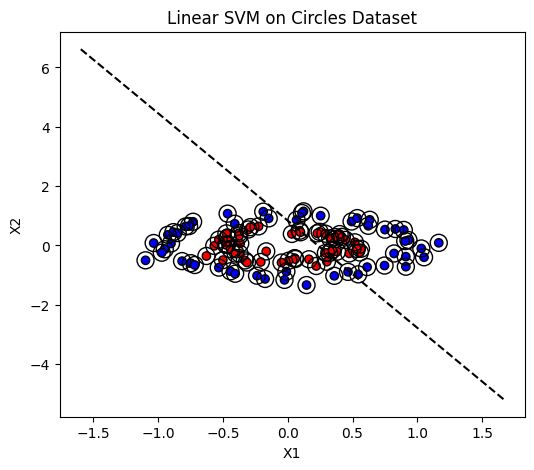

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles

# Data: Circles Dataset
X_circles, y_circles = make_circles(n_samples=100, noise=0.1, factor=0.5, random_state=0)

# Train Linear SVM on Circles
clf_linear_circles = SVC(kernel='linear')
clf_linear_circles.fit(X_circles, y_circles)

# Parameters
w_circles = clf_linear_circles.coef_[0]
b_circles = clf_linear_circles.intercept_[0]

# Decision boundary for Linear Circles
x_circles_line = np.linspace(X_circles[:, 0].min() - 0.5, X_circles[:, 0].max() + 0.5, 100)
epsilon = 1e-10 # To avoid division by zero
y_circles_line = -(w_circles[0]*x_circles_line + b_circles) / (w_circles[1] + epsilon)

# Plot Linear Circles SVM
plt.figure(figsize=(6, 5))
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='bwr', edgecolors='k')
plt.plot(x_circles_line, y_circles_line, 'k--')
plt.scatter(clf_linear_circles.support_vectors_[:, 0],
            clf_linear_circles.support_vectors_[:, 1],
            s=150, facecolors='none', edgecolors='k')
plt.xlabel("X1"); plt.ylabel("X2")
plt.title("Linear SVM on Circles Dataset")
plt.show()

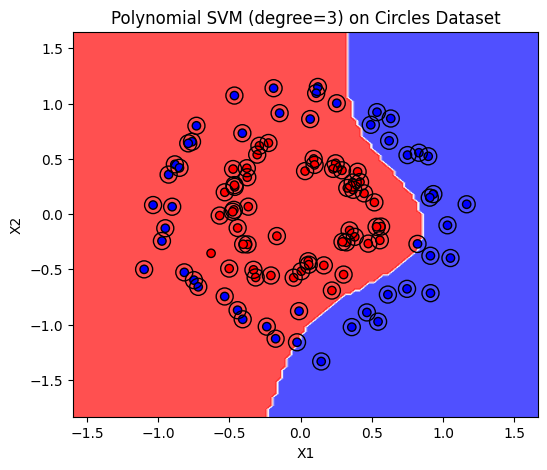

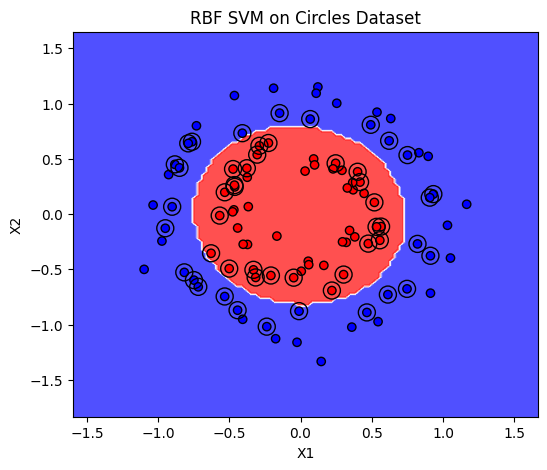

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles

# Reuse Circles Data (X_circles, y_circles) from previous cell, or redefine if running standalone
if 'X_circles' not in locals():
    X_circles, y_circles = make_circles(n_samples=100, noise=0.1, factor=0.5, random_state=0)

# Create meshgrid for decision boundaries
x_min_c, x_max_c = X_circles[:, 0].min() - 0.5, X_circles[:, 0].max() + 0.5
y_min_c, y_max_c = X_circles[:, 1].min() - 0.5, X_circles[:, 1].max() + 0.5
xx_c, yy_c = np.meshgrid(np.linspace(x_min_c, x_max_c, 100),
                         np.linspace(y_min_c, y_max_c, 100))

# Train Polynomial SVM on Circles
clf_poly_circles = SVC(kernel='poly', degree=3)
clf_poly_circles.fit(X_circles, y_circles)
Z_poly_circles = clf_poly_circles.predict(np.c_[xx_c.ravel(), yy_c.ravel()])
Z_poly_circles = Z_poly_circles.reshape(xx_c.shape)

# Plot Polynomial Circles SVM
plt.figure(figsize=(6, 5))
plt.contourf(xx_c, yy_c, Z_poly_circles, alpha=0.8, cmap='bwr')
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='bwr', edgecolors='k')
plt.scatter(clf_poly_circles.support_vectors_[:, 0],
            clf_poly_circles.support_vectors_[:, 1],
            s=150, facecolors='none', edgecolors='k', label='Support Vectors')
plt.xlabel("X1"); plt.ylabel("X2")
plt.title("Polynomial SVM (degree=3) on Circles Dataset")
plt.show()

# Train RBF SVM on Circles
clf_rbf_circles = SVC(kernel='rbf', gamma='auto') # Using 'auto' gamma for simplicity
clf_rbf_circles.fit(X_circles, y_circles)
Z_rbf_circles = clf_rbf_circles.predict(np.c_[xx_c.ravel(), yy_c.ravel()])
Z_rbf_circles = Z_rbf_circles.reshape(xx_c.shape)

# Plot RBF Circles SVM
plt.figure(figsize=(6, 5))
plt.contourf(xx_c, yy_c, Z_rbf_circles, alpha=0.8, cmap='bwr')
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='bwr', edgecolors='k')
plt.scatter(clf_rbf_circles.support_vectors_[:, 0],
            clf_rbf_circles.support_vectors_[:, 1],
            s=150, facecolors='none', edgecolors='k', label='Support Vectors')
plt.xlabel("X1"); plt.ylabel("X2")
plt.title("RBF SVM on Circles Dataset")
plt.show()

In [ ]:
# Train RBF SVM
clf_rbf = SVC(kernel='rbf')
clf_rbf.fit(X, y)

# Predict the class for each point in the meshgrid (reusing xx, yy)
Z_rbf = clf_rbf.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = Z_rbf.reshape(xx.shape)

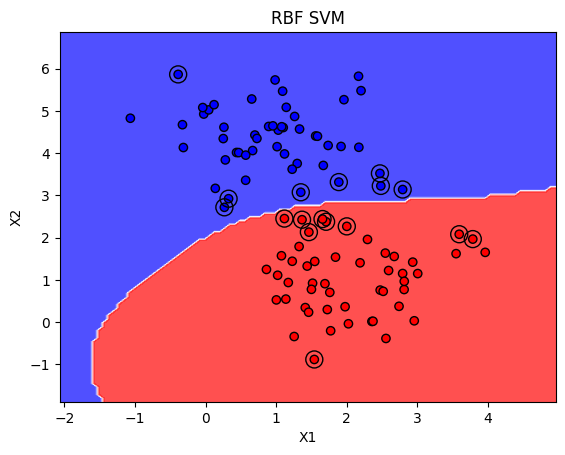

In [ ]:
# Plot RBF SVM
plt.contourf(xx, yy, Z_rbf, alpha=0.8, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.scatter(clf_rbf.support_vectors_[:, 0],
            clf_rbf.support_vectors_[:, 1],
            s=150, facecolors='none', edgecolors='k', label='Support Vectors')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("RBF SVM")
plt.show()